In [3]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
print(data.keys())
print(data.target_names)
X = data.data
y = data.target

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
['malignant' 'benign']


In [2]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
## Creating the model
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

In [6]:
# Training the model
model.fit(X_train, y_train)

GaussianNB()

Learn from the training data how the features are related to each class.

**Logistic Regression** learns coefficients (β₀, β₁, …, β₃₀) using **Maximum Likelihood Estimation (MLE) and optimization**. **Naive Bayes**, on the other hand, does not learn coefficients; it estimates probabilities such as (P(Malignant)), (P(Benign)), and the probability of each feature value given each class. Since we are using **GaussianNB**, it assumes that each numerical feature approximately follows a Gaussian (normal) distribution within each class and therefore learns the **mean and variance** of each feature for both malignant and benign observations. It does this by separating the training data into the two classes and calculating these statistics for all 30 features. It is called **“Naive”** because it assumes that the features are **conditionally independent given the class**—in other words, once we know whether a tumor is malignant or benign, each feature is treated as providing separate evidence, even though features such as radius, perimeter, and area may actually be related.


In [7]:
## See what it has learned
print(model.class_prior_)

[0.37142857 0.62857143]


In [8]:
## Stats
print(model.theta_.shape)

(2, 30)


This means two classes that has 30 features

`theta_` contains the estimated mean of each feature for each class.

In [9]:
print(model.theta_)

[[1.74169231e+01 2.14923077e+01 1.15012959e+02 9.75013609e+02
  1.02531124e-01 1.43885148e-01 1.59455266e-01 8.67635503e-02
  1.93533136e-01 6.26227219e-02 6.00757988e-01 1.20041598e+00
  4.28259763e+00 7.18094675e+01 6.75819527e-03 3.17857870e-02
  4.18483432e-02 1.50038935e-02 2.06236627e-02 3.97157988e-03
  2.10274556e+01 2.92200592e+01 1.40713964e+02 1.41022781e+03
  1.44440769e-01 3.71363373e-01 4.51448994e-01 1.81149467e-01
  3.26636095e-01 9.11269822e-02]
 [1.21680559e+01 1.78216434e+01 7.82140909e+01 4.64910839e+02
  9.17334615e-02 7.98258741e-02 4.72053007e-02 2.55395140e-02
  1.73751049e-01 6.28359790e-02 2.84577273e-01 1.20402867e+00
  2.01659545e+00 2.13169266e+01 7.12550350e-03 2.20011573e-02
  2.74909122e-02 1.00562413e-02 2.05438776e-02 3.73115490e-03
  1.34032587e+01 2.33585664e+01 8.72421678e+01 5.61890210e+02
  1.23904301e-01 1.82647238e-01 1.70089682e-01 7.46106678e-02
  2.69150350e-01 7.95783566e-02]]


The main difference is that **Logistic Regression learns coefficients** and uses the **sigmoid function with MLE and optimization**, while **Naive Bayes learns probability distributions** and uses **Bayes’ theorem**. Logistic Regression stores its learned values in `coef_`, whereas Gaussian Naive Bayes stores statistics such as `theta_`, `var_`, and `class_prior_`. Therefore, when we run `model_nb.fit(X_train, y_train)`, Naive Bayes does not find 30 coefficients like Logistic Regression; instead, it estimates the probability information needed to calculate the **posterior probability** for new observations.


In [11]:
## Making predictions
y_pred = model.predict(X_test)
print(y_pred[:10])

[1 0 0 1 1 0 0 0 1 1]


For a test patient with measurements such as **mean radius, mean texture, mean area, worst concavity**, and the other features, Naive Bayes calculates the **posterior probability** of each class: (P(Malignant|X)) and (P(Benign|X)). It then compares these probabilities and chooses the class with the higher probability. For example, if (P(Malignant|X)=0.20) and (P(Benign|X)=0.80), the model predicts **1 → benign** because 0.80 is greater than 0.20. This is essentially what `model.predict(X_test)` returns: the **final class prediction** based on the calculated probabilities. Recall the YT video about normal and spam messages with some words (Like Dear, Friend, Money and Lunch)


In [14]:
import numpy as np
np.set_printoptions(suppress=True, precision=6)

In [15]:
# Looking to probabilities
y_prob = model.predict_proba(X_test)
print(y_prob[:5])

[[0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]


In [16]:
## to show benign probabilities
y_prob_benign = model.predict_proba(X_test)[:, 1]
print(y_prob_benign[:5])

[1. 0. 0. 1. 1.]


In [17]:
import numpy as np

np.set_printoptions(precision=15)
print(model.predict_proba(X_test[:5]))

[[0.000000002426257 0.999999997573743]
 [1.                0.               ]
 [0.999999999392127 0.000000000607873]
 [0.000000000015082 0.999999999984919]
 [0.00000000000002  0.99999999999998 ]]


Did this to check why pytho was rounding. 
Naive Bayes can be very confident because of its conditional-independence assumption and the multiplication of likelihoods across many features

In [18]:
## Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[40  3]
 [ 0 71]]


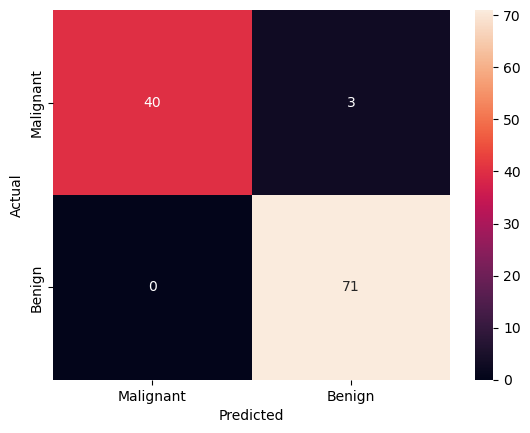

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
## Testing accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {accuracy * 100:.2f}%")

Testing Accuracy: 97.37%


In [22]:
## Classification Report (Precision, Recall, and F1-score)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



For **malignant (0)**, the Naive Bayes model has **100% precision**, meaning that when it predicts malignant, it is correct every time. Its **93% recall** means it correctly detects 93% of all actual malignant cases, while its **96% F1-score** shows a strong balance between precision and recall. For **benign (1)**, the model has **96% precision**, meaning that 96% of its benign predictions are correct, and **100% recall**, meaning it correctly identifies all actual benign cases. Its **98% F1-score** indicates an excellent balance between precision and recall. Overall, the model achieved **97% accuracy**, correctly classifying about 97% of the 114 test observations.
